# Heart Disesase Prediction

In [218]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as ply
import seaborn as sns


In [219]:
df=pd.read_csv("/home/user/Downloads/heart.csv")

In [220]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [221]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [222]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [224]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [225]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [226]:
# check duplicates
df.duplicated().sum()

723

In [227]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])

Total rows: 1025
Duplicate rows: 723
Unique rows: 302


In [228]:
df.shape

(1025, 14)

In [229]:
df=df.drop_duplicates()

In [230]:
df.shape

(302, 14)

In [231]:
print("Rows and columns:", df.shape)
print("Duplicates:", df.duplicated().sum())

Rows and columns: (302, 14)
Duplicates: 0


In [232]:
df["target"].value_counts()

1    164
0    138
Name: target, dtype: int64

## Sex Column (`sex`)

- `0` → Female
- `1` → Male

## Target Column (`target`)

- `0` → No Heart Disease
- `1` → Heart Disease

In [233]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [234]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## Extract the Numerical and Categorical Feature

In [235]:
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [236]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

- check the unique values in the each column

In [237]:
for col in df.columns:
    print(col, ":", df[col].unique())

age : [52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]
sex : [1 0]
cp : [0 1 2 3]
trestbps : [125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]
chol : [212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 264 276 322 214 273 253 176 284 305 168
 407 290 277 262 195 166 178 141]
fbs :

In [238]:
df[numeric_features].describe()

,age,trestbps,chol,thalach,oldpeak
count,302.00000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046
std,9.04797,17.563394,51.753489,22.903527,1.161452
min,29.00000,94.000000,126.000000,71.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000
75%,61.00000,140.000000,274.750000,166.000000,1.600000
max,77.00000,200.000000,564.000000,202.000000,6.200000


In [239]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target Distribution

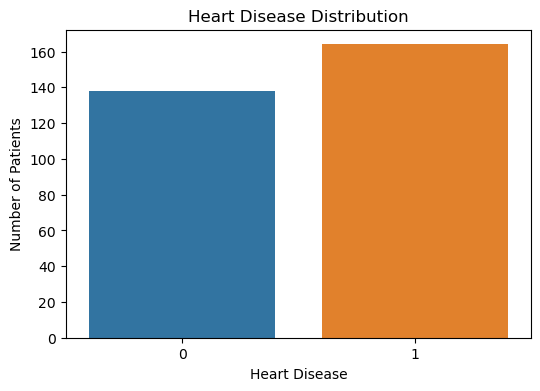

In [240]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

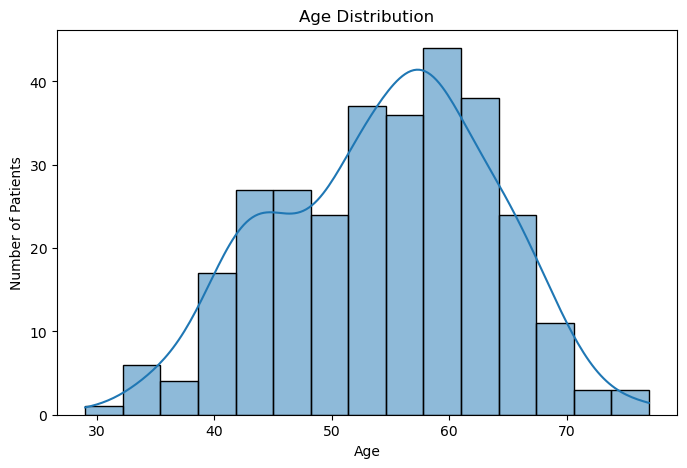

In [241]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="age", bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

- which tells that which age group is present in our dataset
- most of the patients having the age in between the 50 and 60

## 3. Age vs Target

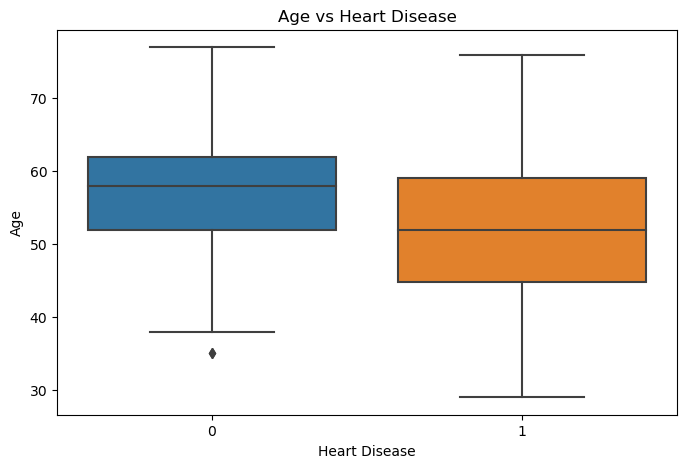

In [242]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

In [243]:
df.groupby("target")["age"].median()

target
0    58.0
1    52.0
Name: age, dtype: float64

## Cholesterol Distributuion

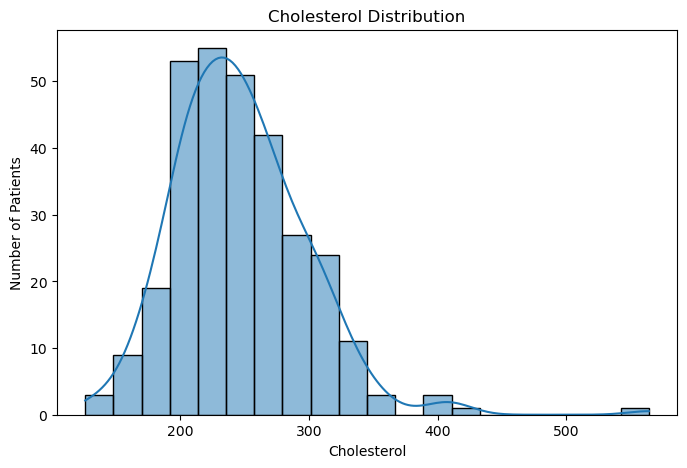

In [244]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="chol", bins=20, kde=True)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")

plt.show()

# Cholesterol Vs Heart Disease

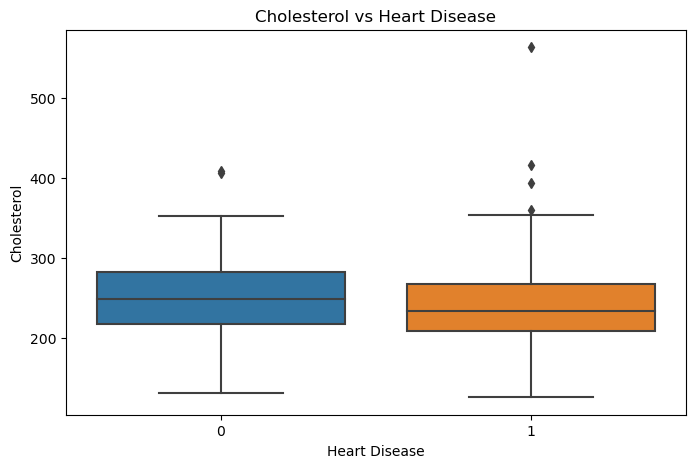

In [245]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="chol", data=df)

plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")

plt.show()

## Chest Pain Type vs Heart Disease

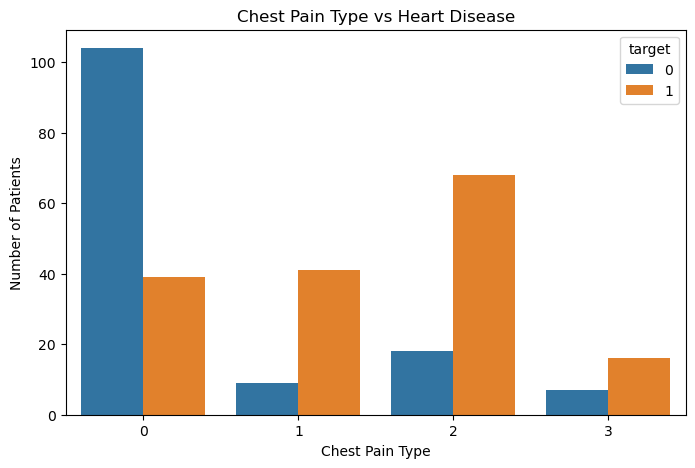

In [246]:
plt.figure(figsize=(8,5))

sns.countplot(x="cp", hue="target", data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.show()

## Correlation

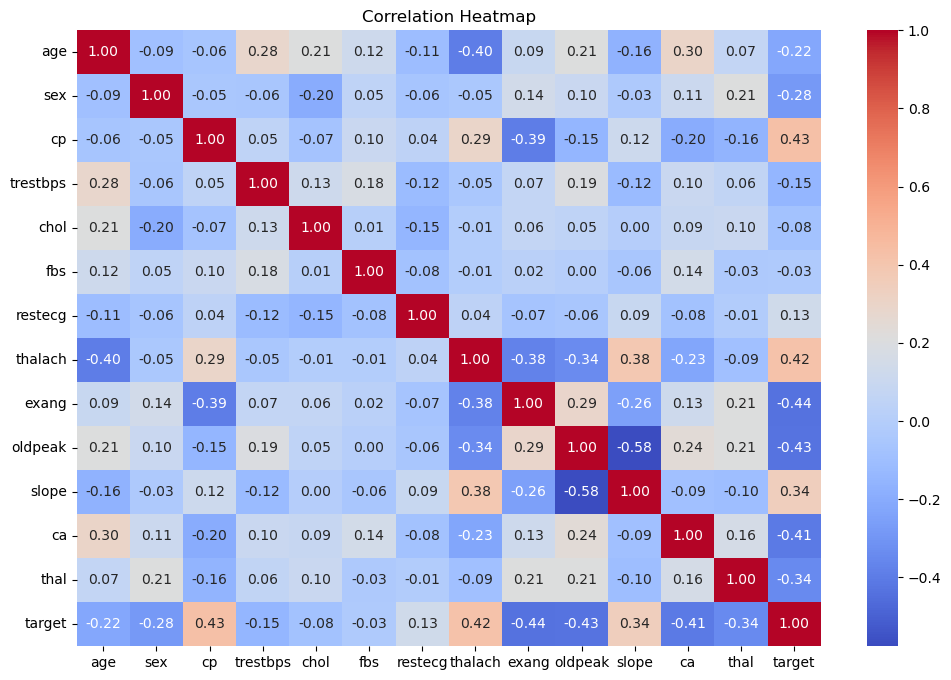

In [247]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Exercise-Induced Angina vs Heart Disease

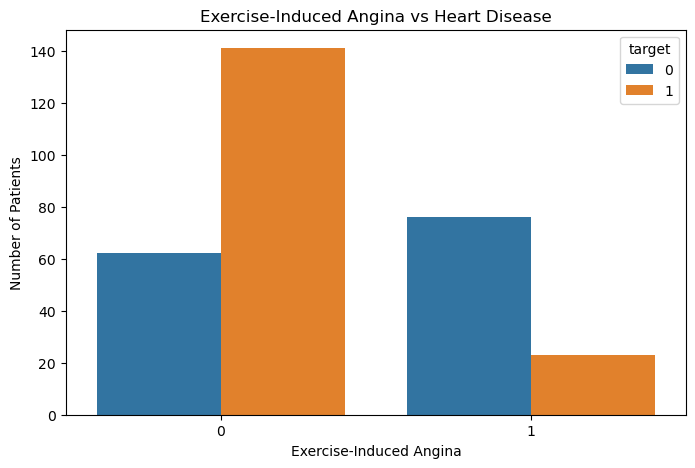

In [248]:
plt.figure(figsize=(8,5))

sns.countplot(x="exang", hue="target", data=df)

plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

plt.show()

## Maximum Heart Rate vs Heart Disease

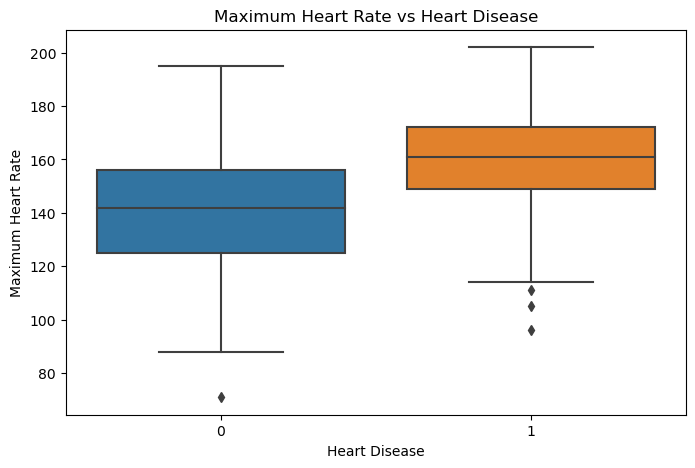

In [249]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="thalach", data=df)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")

plt.show()

## Numerical Features

These columns contain continuous numerical measurements:

- `age` → Age
- `trestbps` → Resting blood pressure
- `chol` → Cholesterol
- `thalach` → Maximum heart rate
- `oldpeak` → ST depression

### Numerical Columns

```python
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

## Categorical Features

- `sex` → 0 = Female, 1 = Male
- `cp` → Chest pain type
- `fbs` → Fasting blood sugar
- `restecg` → Resting ECG result
- `exang` → Exercise-induced angina
- `slope` → Slope of the peak exercise ST segment
- `ca` → Number of major vessels
- `thal` → Thalassemia result

### Categorical Columns

```python
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

## Detection Of Outliers

In [250]:
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}")
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))
    print()

age
Lower bound: 28.5
Upper bound: 80.5
Number of outliers: 0

trestbps
Lower bound: 90.0
Upper bound: 170.0
Number of outliers: 9

chol
Lower bound: 115.375
Upper bound: 370.375
Number of outliers: 5

thalach
Lower bound: 84.125
Upper bound: 215.125
Number of outliers: 1

oldpeak
Lower bound: -2.4000000000000004
Upper bound: 4.0
Number of outliers: 5



## Handle The Outliers

In [251]:
''' for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)'''

' for col in numeric_features:\n    Q1 = df[col].quantile(0.25)\n    Q3 = df[col].quantile(0.75)\n\n    IQR = Q3 - Q1\n\n    lower_bound = Q1 - 1.5 * IQR\n    upper_bound = Q3 + 1.5 * IQR\n\n    df[col] = df[col].clip(lower_bound, upper_bound)'

In [252]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [253]:
x = df.drop("target", axis=1)
y = df["target"]

In [254]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [255]:
y

0      0
1      0
2      0
3      0
4      0
      ..
723    1
733    1
739    0
843    0
878    0
Name: target, Length: 302, dtype: int64

In [256]:
print(x.shape)
print(y.shape)

(302, 13)
(302,)


In [257]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [258]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [259]:
print(y_train.value_counts())

1    131
0    110
Name: target, dtype: int64


In [260]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (302, 13)
y shape: (302,)

Target distribution:
1    164
0    138
Name: target, dtype: int64


In [261]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (241, 13)
X_test: (61, 13)
y_train: (241,)
y_test: (61,)


In [262]:
print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
1    131
0    110
Name: target, dtype: int64

Testing:
1    33
0    28
Name: target, dtype: int64


In [263]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3
199,50,1,0,144,200,0,0,126,1,0.9,1,0,3
479,58,1,0,128,216,0,0,131,1,2.2,1,3,3
460,69,1,2,140,254,0,0,146,0,2.0,1,3,3
169,45,0,1,112,160,0,1,138,0,0.0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,43,0,2,122,213,0,1,165,0,0.2,1,0,2
320,53,0,0,130,264,0,0,143,0,0.4,1,0,2
472,58,0,0,130,197,0,1,131,0,0.6,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2


In [264]:
X_train_processed = preprocessor.fit_transform(X_train)

In [265]:
X_test_processed = preprocessor.transform(X_test)

In [266]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(241, 30)
(61, 30)


In [267]:
X_train_processed

array([[ 1.42194408, -0.97304069,  5.88290757, ...,  0.        ,
         0.        ,  1.        ],
       [-0.46584105,  0.75650697, -0.88569606, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.42252843, -0.19772622, -0.58817502, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.42252843, -0.07844707, -0.94148125, ...,  0.        ,
         1.        ,  0.        ],
       [-1.13211815, -1.39051771, -1.98280489, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.53299026, -0.79412197,  0.54612394, ...,  0.        ,
         0.        ,  1.        ]])

In [268]:
feature_names = preprocessor.get_feature_names_out()

In [269]:
print(feature_names)

['num__age' 'num__trestbps' 'num__chol' 'num__thalach' 'num__oldpeak'
 'cat__sex_0' 'cat__sex_1' 'cat__cp_0' 'cat__cp_1' 'cat__cp_2' 'cat__cp_3'
 'cat__fbs_0' 'cat__fbs_1' 'cat__restecg_0' 'cat__restecg_1'
 'cat__restecg_2' 'cat__exang_0' 'cat__exang_1' 'cat__slope_0'
 'cat__slope_1' 'cat__slope_2' 'cat__ca_0' 'cat__ca_1' 'cat__ca_2'
 'cat__ca_3' 'cat__ca_4' 'cat__thal_0' 'cat__thal_1' 'cat__thal_2'
 'cat__thal_3']


In [270]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)


In [271]:
X_train_processed_df

,num__age,num__trestbps,num__chol,num__thalach,num__oldpeak,cat__sex_0,cat__sex_1,cat__cp_0,cat__cp_1,cat__cp_2,...,cat__slope_2,cat__ca_0,cat__ca_1,cat__ca_2,cat__ca_3,cat__ca_4,cat__thal_0,cat__thal_1,cat__thal_2,cat__thal_3
158,1.421944,-0.973041,5.882908,0.408240,0.527263,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
199,-0.465841,0.756507,-0.885696,-1.104705,-0.083233,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
479,0.422528,-0.197726,-0.588175,-0.882213,1.050546,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
460,1.644036,0.517949,0.118437,-0.214737,0.876119,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
169,-1.021072,-1.151959,-1.629499,-0.570724,-0.868157,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,-1.243164,-0.555564,-0.643960,0.630732,-0.693730,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
320,-0.132702,-0.078447,0.304388,-0.348232,-0.519302,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
472,0.422528,-0.078447,-0.941481,-0.882213,-0.344874,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
733,-1.132118,-1.390518,-1.982805,1.075716,-0.344874,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


##  Pipeline and Prediction

In [272]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [273]:
models = {
    "Logistic Regression": Pipeline([
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "KNN": Pipeline([
        ("model", KNeighborsClassifier())
    ]),

    "SVM": Pipeline([
        ("model", SVC(random_state=42))
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ])
}

In [277]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [278]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_processed, y_train)

    # Predict
    y_pred = model.predict(X_test_processed)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x743a3408c4a0>
Traceback (most recent call last):
  File "/home/user/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/user/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/user/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 's

In [280]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8360655737704918,
  'Precision': 0.8484848484848485,
  'Recall': 0.8484848484848485,
  'F1 Score': 0.8484848484848486},
 {'Model': 'KNN',
  'Accuracy': 0.8360655737704918,
  'Precision': 0.8709677419354839,
  'Recall': 0.8181818181818182,
  'F1 Score': 0.84375},
 {'Model': 'SVM',
  'Accuracy': 0.7868852459016393,
  'Precision': 0.8125,
  'Recall': 0.7878787878787878,
  'F1 Score': 0.8},
 {'Model': 'Decision Tree',
  'Accuracy': 0.7377049180327869,
  'Precision': 0.7741935483870968,
  'Recall': 0.7272727272727273,
  'F1 Score': 0.7500000000000001},
 {'Model': 'Random Forest',
  'Accuracy': 0.8032786885245902,
  'Precision': 0.8181818181818182,
  'Recall': 0.8181818181818182,
  'F1 Score': 0.8181818181818182}]

In [281]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.836066,0.848485,0.848485,0.848485
1,KNN,0.836066,0.870968,0.818182,0.843750
2,SVM,0.786885,0.812500,0.787879,0.800000
3,Decision Tree,0.737705,0.774194,0.727273,0.750000
4,Random Forest,0.803279,0.818182,0.818182,0.818182


In [282]:
results_df.sort_values("Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.836066,0.848485,0.848485,0.848485
1,KNN,0.836066,0.870968,0.818182,0.843750
4,Random Forest,0.803279,0.818182,0.818182,0.818182
2,SVM,0.786885,0.812500,0.787879,0.800000
3,Decision Tree,0.737705,0.774194,0.727273,0.750000


In [283]:
best_model = results_df.loc[results_df["Recall"].idxmax()]

print(best_model)


Model        Logistic Regression
Accuracy                0.836066
Precision               0.848485
Recall                  0.848485
F1 Score                0.848485
Name: 0, dtype: object
